# Energy-gap law a $T = 0$ K para los $k_{NR}$ de `AndersonModelUnfolded`

1. Tomo el `reference_rate` de cada transición `TemperatureDependentInternal*` del modelo, salvo las de `EXCLUDE` (no son las que reporta Anderson 2013).
2. Las llevo a $T=0$ (solo emisión espontánea de fonones, $n=0$) con el factor de Bose–Einstein de la propia transición:
$$k_{NR}(0) = \frac{k_{NR}(T_A)}{\left[1 + n(T_A)\right]^{p}}, \qquad n(T) = \frac{1}{e^{\hbar\omega/k_BT} - 1}, \quad p = \frac{\Delta E}{\hbar\omega}$$
3. Grafico $k_{NR}(0)$ vs $\Delta E$ y ajusto $k_{NR}(0) = B\, e^{-a \Delta E}$.
4. Heatmap de $e^{-a\Delta E}\cdot F(T)$ para todo par de niveles, con el factor absoluto (convención de las clases no-`Ref` de `transitions.py`):
$$F_{\downarrow}(T) = \left[1 + n(T)\right]^{p}, \qquad F_{\uparrow}(T) = n(T)^{p}$$

$p$ es continuo, igual que `Base.p` en `transitions.py` (no `ceil` como en `temperature_dependance.ipynb`).

In [1]:
from upconversion_models.anderson_unfolded import AndersonModelUnfolded
from upconversion_models.transitions import Base
from upconversion_models.utils import k, hc
from jablonski import SingletState
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import pint

u = pint.get_application_registry()
model = AndersonModelUnfolded()
kB = (k / hc).to(1 / (u.cm * u.K)).magnitude  # cm⁻¹ / K


def occupation(T, phonon_wavenumber):
    return 1 / np.expm1(phonon_wavenumber / (kB * T))

## 1. $k_{NR}$ del modelo, llevados a 0 K

`EXCLUDE`: la termalización $6h \leftrightarrow 6s$ (no es de Anderson, nivel 6 único) y $7 \to 6h$
(Anderson reporta $7\to6$ con el nivel 6 en 18300 cm⁻¹, o sea $7\to6s$, $\Delta E = 2200$ cm⁻¹; el modelo hoy la conecta a $6h$, $\Delta E = 1300$ cm⁻¹).

In [2]:
EXCLUDE = {"Er6h→Er6s", "Er6s→Er6h", "Er7→Er6h"}

rows = []
for t in model._yield(Base):
    name = f"{t.source}→{t.target}"
    if name in EXCLUDE:
        continue
    gap = t._gap_wavenumber.default.to(1 / u.cm).magnitude
    phonon = t.phonon_wavenumber.default.to(1 / u.cm).magnitude
    T_A = t.T_A.default.to(u.K).magnitude
    k_ref = t.reference_rate.default.to(1 / u.s).magnitude
    p = gap / phonon
    k_0 = k_ref / (1 + occupation(T_A, phonon)) ** p
    rows.append((name, gap, phonon, T_A, k_ref, k_0))

names = np.array([r[0] for r in rows])
gaps, phonons, T_As, knr_ref, knr = (np.array(col) for col in list(zip(*rows))[1:])

for name, gap, phonon, T_A, k_ref, k_0 in rows:
    print(
        f"{name:>10}  ΔE = {gap:6.0f} cm⁻¹  ħω = {phonon:g} cm⁻¹  "
        f"k_nr({T_A:g} K) = {k_ref:9.3g} s⁻¹  →  k_nr(0 K) = {k_0:9.3g} s⁻¹"
    )

assert len(set(phonons)) == 1 and len(set(T_As)) == 1, "el heatmap asume un único ħω y T_A"
phonon_wavenumber, T0 = phonons[0], T_As[0]

   Er9→Er8  ΔE =   1600 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =  1.76e+06 s⁻¹  →  k_nr(0 K) =  6.85e+05 s⁻¹
   Er8→Er7  ΔE =   4000 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =  4.34e+04 s⁻¹  →  k_nr(0 K) =   4.1e+03 s⁻¹
  Er6h→Er5  ΔE =   4200 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =        26 s⁻¹  →  k_nr(0 K) =      2.18 s⁻¹
  Er6s→Er5  ΔE =   3300 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =        26 s⁻¹  →  k_nr(0 K) =      3.71 s⁻¹
   Er5→Er4  ΔE =   2500 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =         0 s⁻¹  →  k_nr(0 K) =         0 s⁻¹
   Er4→Er3  ΔE =   2300 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =  2.21e+04 s⁻¹  →  k_nr(0 K) =  5.69e+03 s⁻¹
   Er3→Er2  ΔE =   3700 cm⁻¹  ħω = 350 cm⁻¹  k_nr(300 K) =        61 s⁻¹  →  k_nr(0 K) =      6.87 s⁻¹


## 2. $k_{NR}$ vs $\Delta E$ y ajuste exponencial

Ajuste lineal de $\ln k_{NR}(0)$ vs $\Delta E$; las transiciones con $k_{NR}=0$ (Er5→Er4) no entran.

a = 3.830e-03 cm,  B = 6.115e+07 s⁻¹


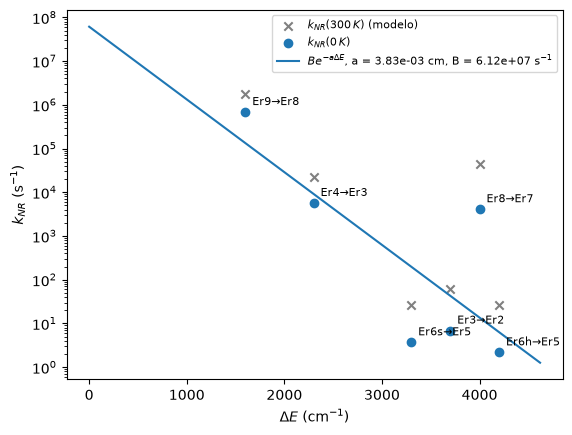

   Er9→Er8  log10(k / fit) = +0.71
   Er8→Er7  log10(k / fit) = +2.48
  Er6h→Er5  log10(k / fit) = -0.46
  Er6s→Er5  log10(k / fit) = -1.73
   Er4→Er3  log10(k / fit) = -0.21
   Er3→Er2  log10(k / fit) = -0.79


In [3]:
valid = knr > 0
slope, intercept = np.polyfit(gaps[valid], np.log(knr[valid]), 1)
a, B = -slope, np.exp(intercept)  # a [cm], B [1/s]
print(f"a = {a:.3e} cm,  B = {B:.3e} s⁻¹")

dE = np.linspace(0, 1.1 * gaps.max(), 200)
fig, ax = plt.subplots()
ax.scatter(gaps[valid], knr_ref[valid], marker="x", c="gray", label=rf"$k_{{NR}}({T0:g}\,K)$ (modelo)")
ax.scatter(gaps[valid], knr[valid], zorder=3, label=r"$k_{NR}(0\,K)$")
for name, g, kk in zip(names[valid], gaps[valid], knr[valid]):
    ax.annotate(name, (g, kk), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.plot(dE, B * np.exp(-a * dE), label=rf"$B e^{{-a\Delta E}}$, a = {a:.2e} cm, B = {B:.2e} s$^{{-1}}$")
ax.set_yscale("log")
ax.set_xlabel(r"$\Delta E$ (cm$^{-1}$)")
ax.set_ylabel(r"$k_{NR}$ (s$^{-1}$)")
ax.legend(fontsize=8)
plt.show()

residuals = np.log10(knr[valid]) - np.log10(B * np.exp(-a * gaps[valid]))
for name, r in zip(names[valid], residuals):
    print(f"{name:>10}  log10(k / fit) = {r:+.2f}")

## 3. Heatmap $e^{-a\Delta E}\cdot F(T)$

Fila = nivel de origen, columna = destino (misma convención que `temperature_dependance.ipynb`).
Debajo de la diagonal: relajación ($F_\downarrow$), arriba: excitación térmica ($F_\uparrow$).
Borde rojo: transiciones usadas en el ajuste; borde gris punteado: las de `EXCLUDE`.
Multiplicando por $B$ se obtiene la tasa estimada en s⁻¹.

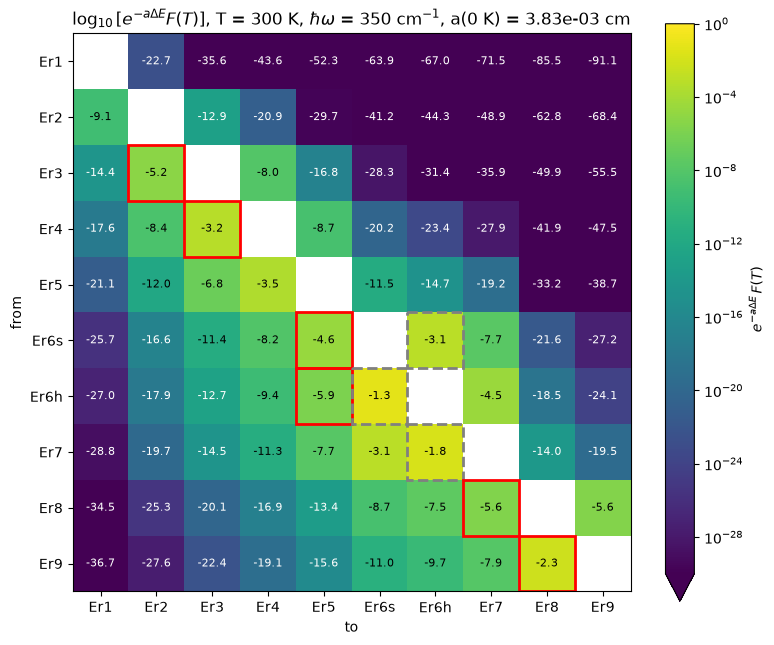

In [4]:
# _yield repite los estados de cada sub-sistema: dedup por nombre y ordeno por energía
levels = {str(l): l for l in model._yield(SingletState) if str(l).startswith("Er")}
levels = sorted(levels.values(), key=lambda l: l.energy)
labels = [str(l) for l in levels]
E = np.array([(l.energy / hc).to(1 / u.cm).magnitude for l in levels])


def gap_law_heatmap(T):
    n = occupation(T, phonon_wavenumber)
    V = np.full((len(levels), len(levels)), np.nan)
    for i, Ei in enumerate(E):
        for j, Ej in enumerate(E):
            if i == j:
                continue
            dE = abs(Ei - Ej)
            p = dE / phonon_wavenumber
            F = (1 + n) ** p if Ei > Ej else n**p
            V[i, j] = np.exp(-a * dE) * F
    return V


def plot_heatmap(T, vmin=1e-30):
    V = gap_law_heatmap(T)
    fig, ax = plt.subplots(figsize=(9, 7.5))
    norm = LogNorm(vmin=vmin, vmax=1)
    im = ax.imshow(V, norm=norm)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            if np.isfinite(V[i, j]):
                ax.text(j, i, f"{np.log10(V[i, j]):.1f}", ha="center", va="center", fontsize=8,
                        color="k" if norm(V[i, j]) > 0.6 else "w")
            name = f"{labels[i]}→{labels[j]}"
            if name in names[valid]:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec="r", lw=2))
            elif name in EXCLUDE:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec="gray", lw=2, ls="--"))
    fig.colorbar(im, label=r"$e^{-a\Delta E}\,F(T)$", extend="min")
    ax.set_xticks(np.arange(len(levels)), labels)
    ax.set_yticks(np.arange(len(levels)), labels)
    ax.set_ylabel("from")
    ax.set_xlabel("to")
    ax.set_title(
        rf"$\log_{{10}}[e^{{-a\Delta E}} F(T)]$, T = {T:g} K, "
        rf"$\hbar\omega$ = {phonon_wavenumber:g} cm$^{{-1}}$, a(0 K) = {a:.2e} cm"
    )
    plt.show()
    return V


V = plot_heatmap(T0)

Mismo heatmap a otra temperatura (para ver qué transiciones se prenden al calentar):

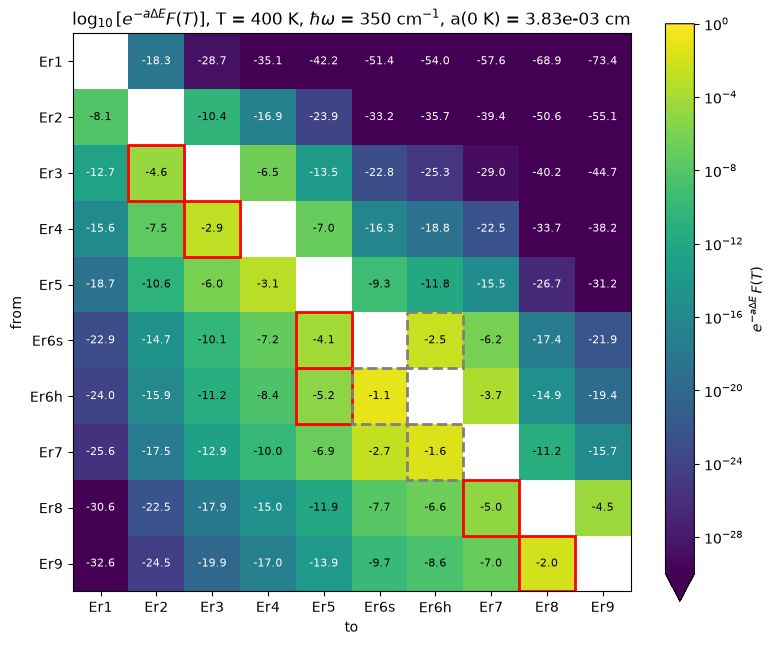

In [5]:
V_hot = plot_heatmap(400)